<a href="https://colab.research.google.com/github/varshithadaraboina/Research-Paper/blob/main/Explainable_AI_Research_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Explainable Deep Learning for Skin Lesion Classification

In [ ]:
pip install shap lime scikit-learn matplotlib seaborn imbalanced-learn


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

# Load the dataset
url = '/content/HAM10000_metadata.csv'
df = pd.read_csv(url)

# Preprocessing
df = df.dropna()  # Drop rows with missing values
df['dx'] = LabelEncoder().fit_transform(df['dx'])  # Encode labels

# Drop 'image_id' and 'lesion_id' as they are not features
df = df.drop(['image_id', 'lesion_id'], axis=1)

# One-hot encode categorical features
df = pd.get_dummies(df, columns=['dx_type', 'sex', 'localization'], drop_first=True)

X = df.drop('dx', axis=1)
y = df['dx']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

In [ ]:
# Initialize and train the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_res, y_train_res)

# Evaluate the model
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.17      0.48      0.25        65
           1       0.18      0.45      0.25        91
           2       0.44      0.29      0.35       225
           3       0.23      0.52      0.32        29
           4       0.32      0.41      0.36       225
           5       0.97      0.75      0.84      1336
           6       0.20      0.43      0.28        21

    accuracy                           0.63      1992
   macro avg       0.36      0.48      0.38      1992
weighted avg       0.76      0.63      0.67      1992



/tmp/ipython-input-982812095.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar")


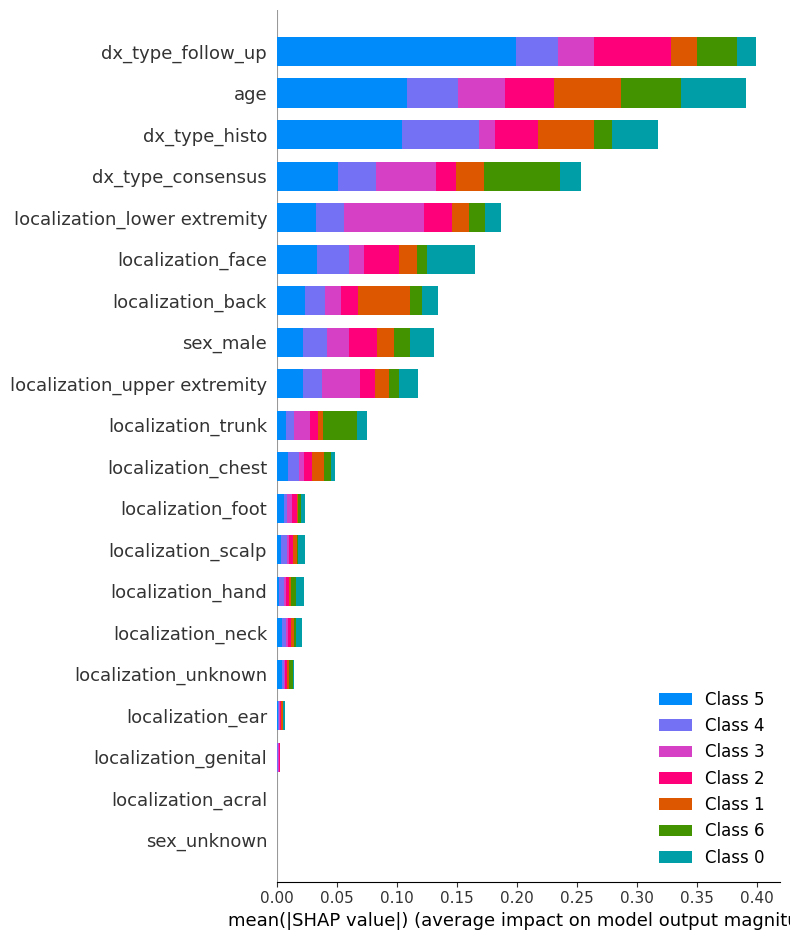

In [ ]:
# Initialize SHAP explainer
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary plot
shap.summary_plot(shap_values, X_test, plot_type="bar")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


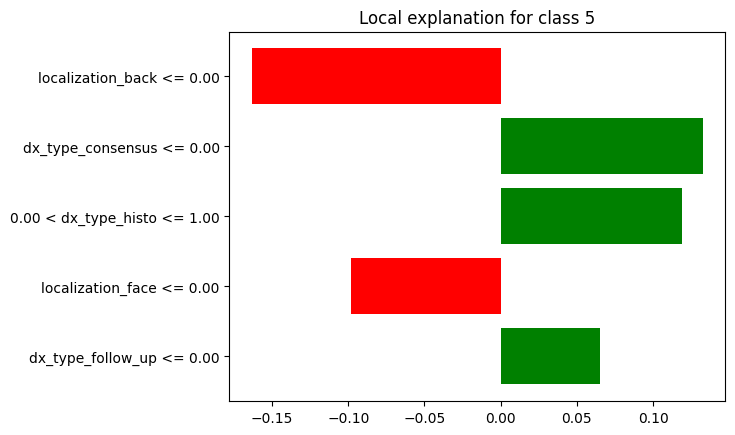

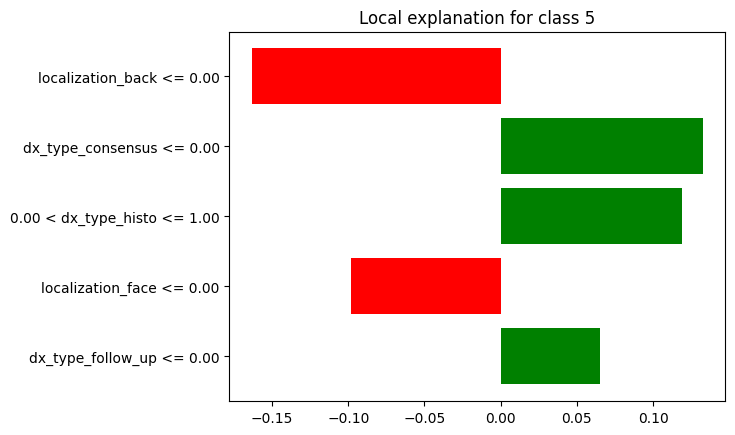

In [ ]:
# Initialize LIME explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_res.values,
    training_labels=y_train_res.values,
    mode="classification",
    class_names=df['dx'].unique(),
    feature_names=X.columns,
    discretize_continuous=True
)

# Select a random instance from the test set
i = 25
exp = lime_explainer.explain_instance(X_test.iloc[i].values, clf.predict_proba, num_features=5)

# Plot LIME explanation
exp.as_pyplot_figure()


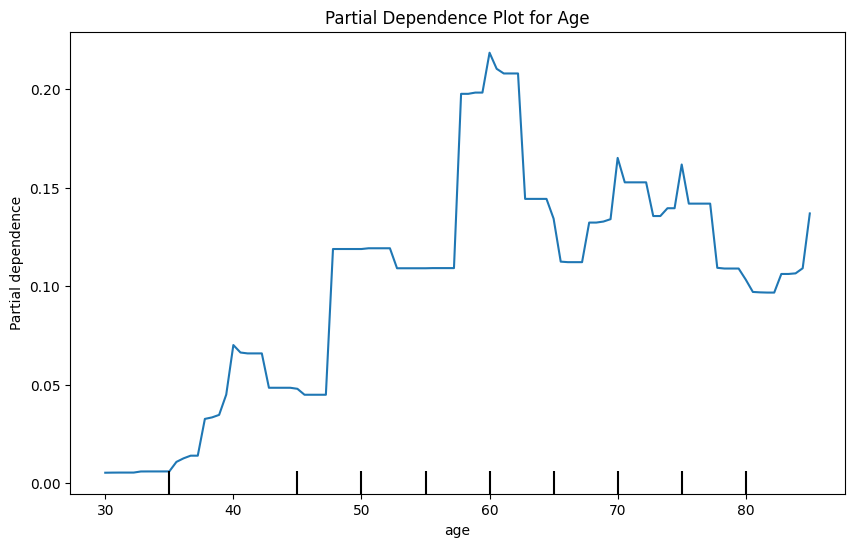

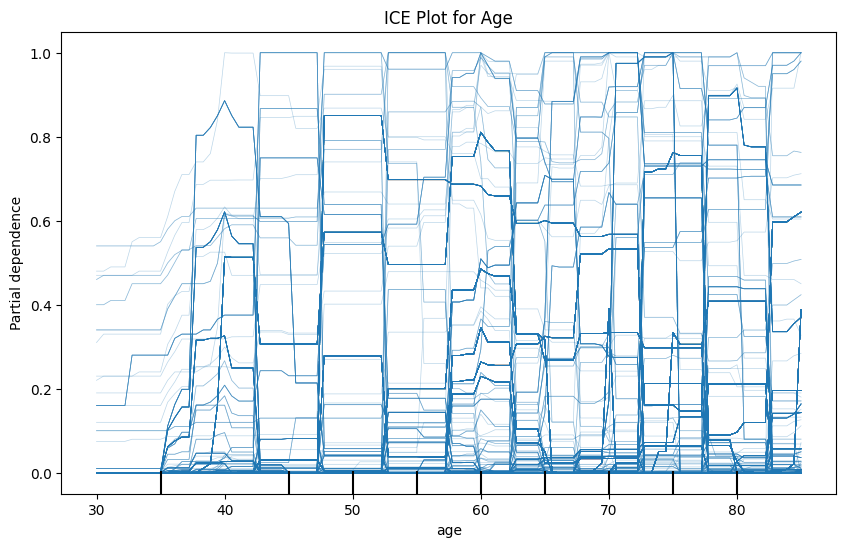

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# PDP for a specific feature (e.g., 'age')
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(clf, X_train_res, features=['age'], ax=ax, target=0)
ax.set_title('Partial Dependence Plot for Age')
plt.show()

# ICE for the same feature (e.g., 'age')
fig, ax = plt.subplots(figsize=(10, 6))
PartialDependenceDisplay.from_estimator(clf, X_train_res, features=['age'], kind='individual', ax=ax, target=0)
ax.set_title('ICE Plot for Age')
plt.show()

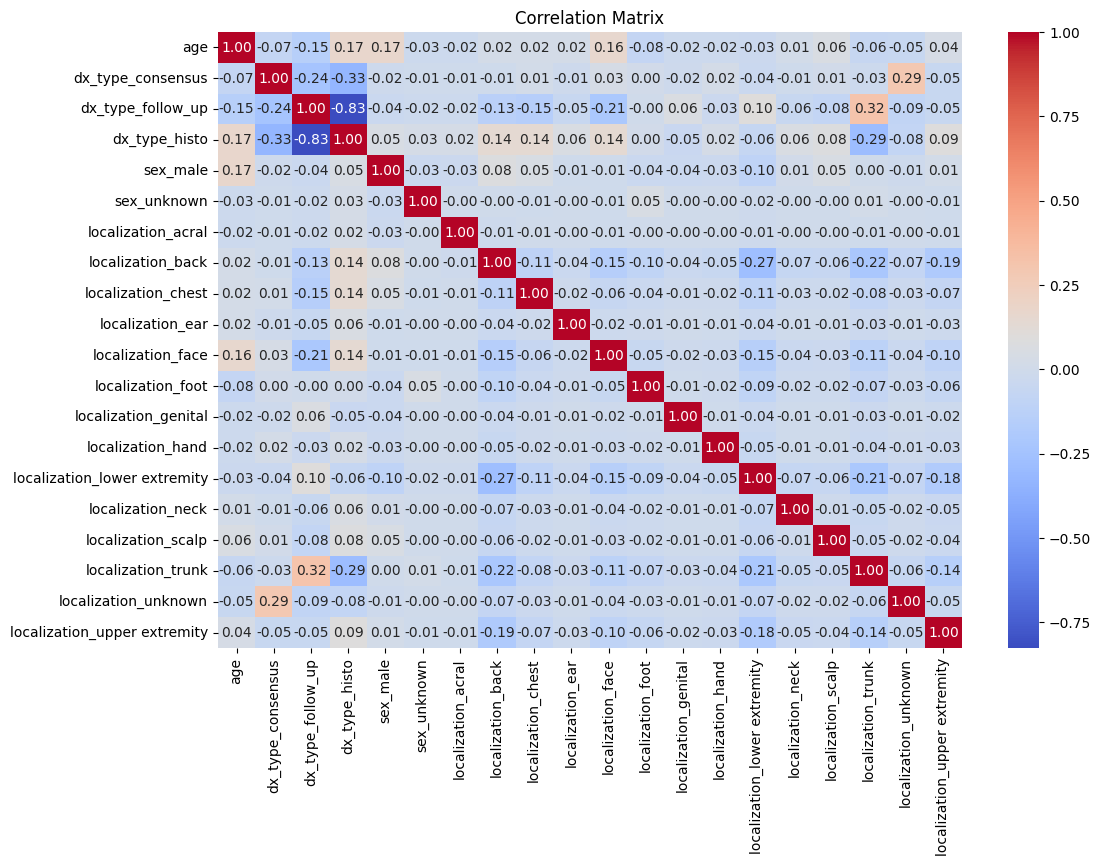

In [ ]:
# Compute correlation matrix
corr_matrix = X.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()


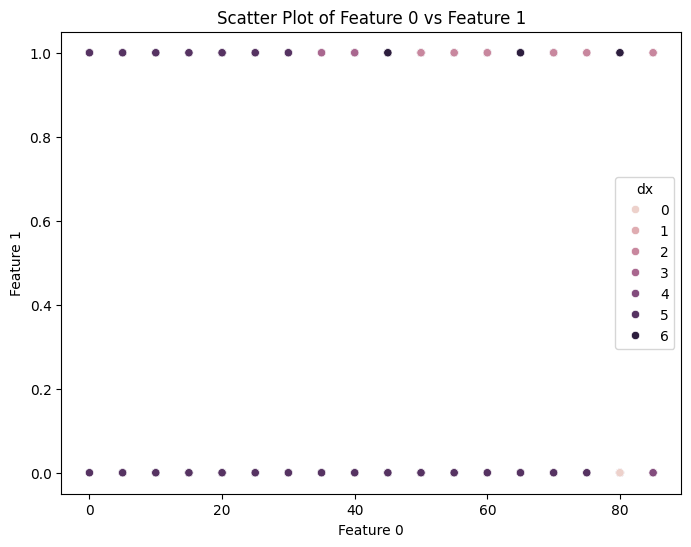

In [ ]:
# Scatter plot for two features
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test.iloc[:, 0], y=X_test.iloc[:, 1], hue=y_test)
plt.title('Scatter Plot of Feature 0 vs Feature 1')
plt.xlabel('Feature 0')
plt.ylabel('Feature 1')
plt.show()


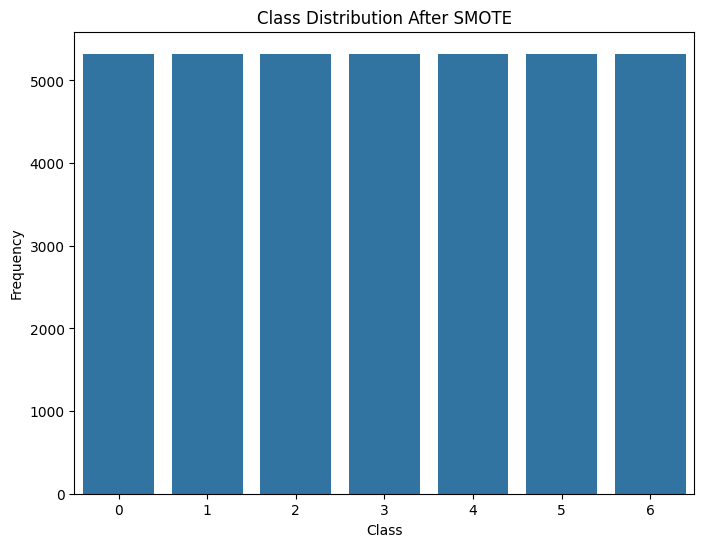

In [ ]:
# Plot class distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_res)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Frequency')
plt.show()


**Ensemble Models on HAM10000 metadata**


📊 Ensemble Model Performance:

               Model  Accuracy  Precision    Recall  F1-Score
0            Bagging  0.702446   0.317668  0.237463  0.247977
1      Random Forest  0.705442   0.312060  0.236164  0.244583
2      Voting (Soft)  0.706940   0.307624  0.226585  0.234139
3           Stacking  0.707439   0.285536  0.220148  0.215166
4  Gradient Boosting  0.700949   0.324781  0.211780  0.208947
5           AdaBoost  0.686470   0.208637  0.195553  0.193577


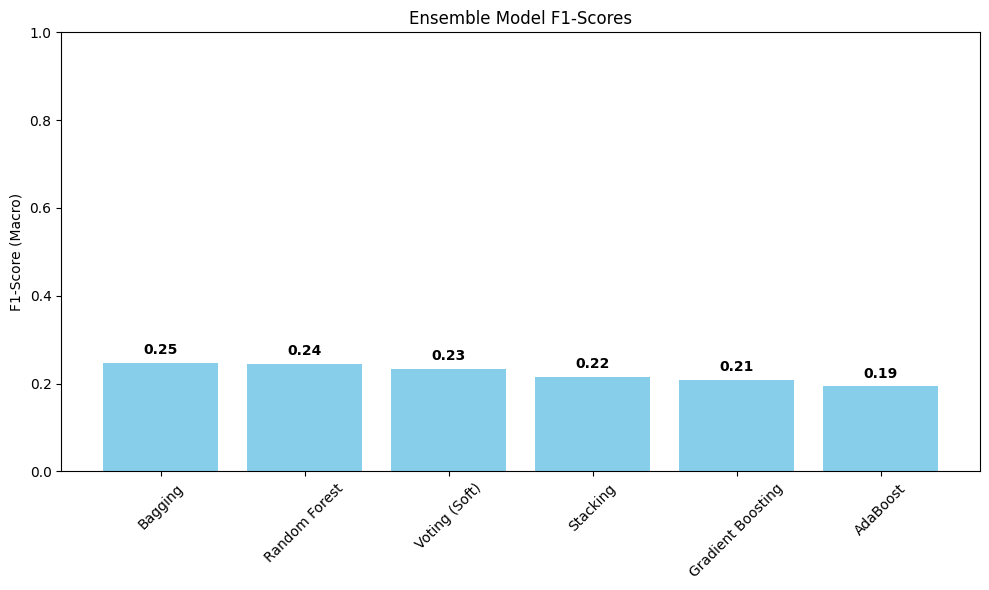

In [ ]:
# 🧠 Ensemble Models on HAM10000 metadata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    BaggingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# 1️⃣ Load dataset
df = pd.read_csv("/content/HAM10000_metadata.csv")

# 2️⃣ Select features & target
features = ["age", "sex", "localization"]
target = "dx"
df = df[features + [target]].dropna(subset=[target])

# 3️⃣ Preprocessing
num_features = ["age"]
cat_features = ["sex", "localization"]

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

# 4️⃣ Encode target
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

X = df[features]
y = df[target]

# 5️⃣ Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6️⃣ Define Ensemble Models (compatible with sklearn >=1.2)
models = {
    "Random Forest": RandomForestClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Bagging": BaggingClassifier(estimator=DecisionTreeClassifier()),  # ✅ fixed
    "Voting (Soft)": VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier()),
            ('ada', AdaBoostClassifier()),
            ('gb', GradientBoostingClassifier())
        ],
        voting='soft'
    ),
    "Stacking": StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier()),
            ('ada', AdaBoostClassifier()),
            ('gb', GradientBoostingClassifier())
        ],
        final_estimator=LogisticRegression(max_iter=500)
    )
}

# 7️⃣ Train & Evaluate
results = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, average="macro", zero_division=0)
    })

# 8️⃣ Show Results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)
print("\n📊 Ensemble Model Performance:\n")
print(results_df)

# 9️⃣ Plot F1-Scores
plt.figure(figsize=(10,6))
plt.bar(results_df["Model"], results_df["F1-Score"], color='skyblue')
plt.title("Ensemble Model F1-Scores")
plt.ylabel("F1-Score (Macro)")
plt.ylim(0, 1)
plt.xticks(rotation=45)
for i, v in enumerate(results_df["F1-Score"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Apply all ML models on HAM10000 metadata + show visual comparison**


🚀 Training and Evaluating Models...

📊 Model Performance Comparison:

              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Decision Tree  0.703944   0.289358 0.236710  0.244095 0.821125
      Random Forest  0.707938   0.308079 0.233295  0.241372 0.821923
                KNN  0.649526   0.232694 0.227151  0.221870 0.676816
  Gradient Boosting  0.700949   0.324781 0.211780  0.208947 0.793535
Logistic Regression  0.696955   0.395874 0.209384  0.208598 0.771966
           AdaBoost  0.686470   0.208637 0.195553  0.193577 0.738550
                SVM  0.701947   0.209257 0.197462  0.187585 0.725196
        Naive Bayes  0.041937   0.197032 0.246829  0.051023 0.656536

🏆 Best Model based on F1-Score: Decision Tree

🧩 Confusion Matrix for Best Model:

    0  1   2  3   4     5  6
0  10  4  18  0   9    24  0
1   0  6  23  0   9    65  0
2  10  5  87  0  14   101  3
3   0  0   0  0   1    22  0
4   7  8  32  0  20   156  0
5   6  6  28  0  14  1287  0
6   0  0   3  0   0  

/tmp/ipython-input-655380762.py:128: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


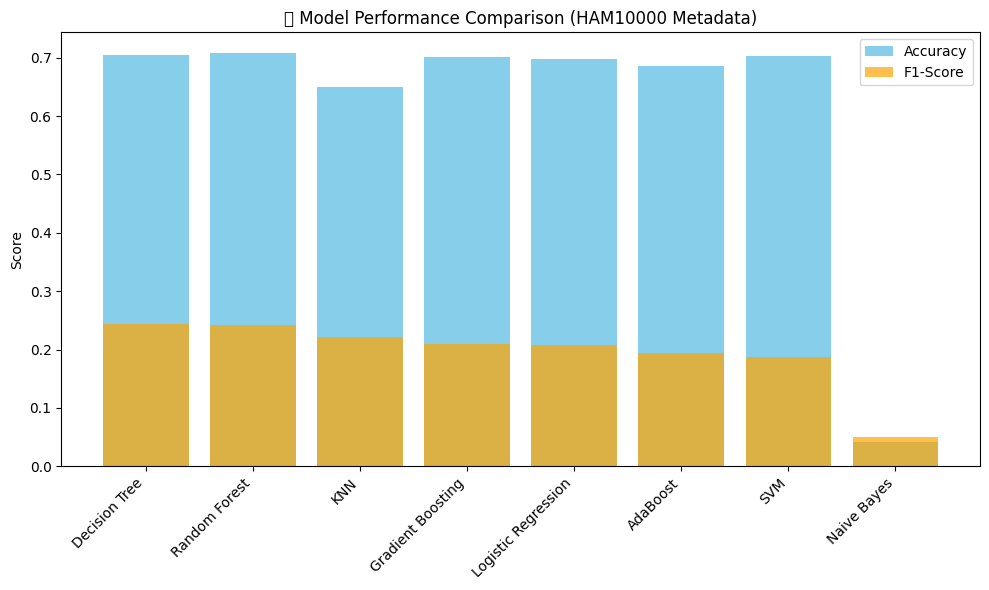

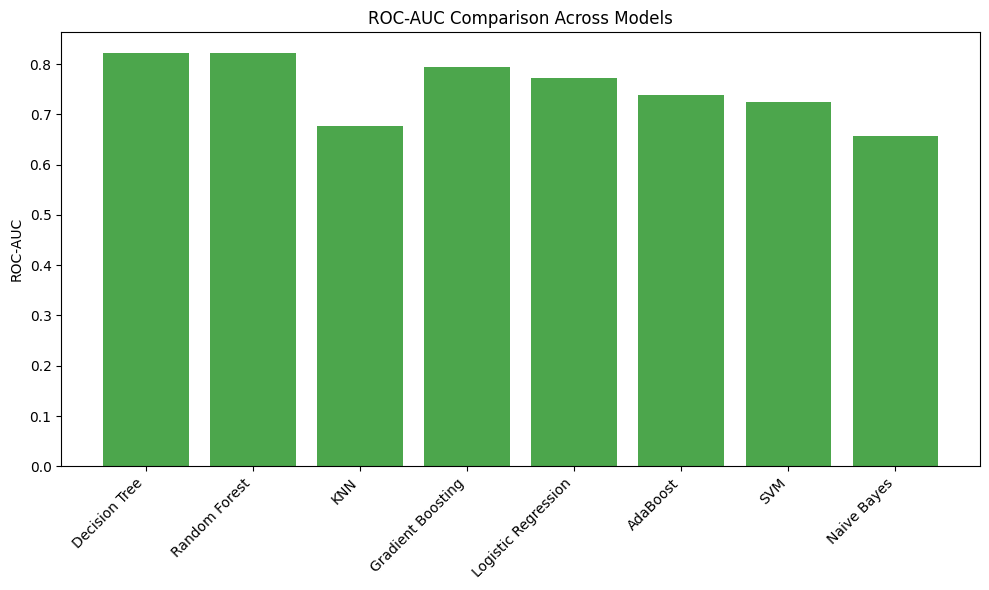

In [ ]:
# 📊 Apply all ML models on HAM10000 metadata + show visual comparison
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# 1️⃣ Load dataset
df = pd.read_csv("/content/HAM10000_metadata.csv")

# 2️⃣ Select features & target
features = ["age", "sex", "localization"]
target = "dx"
df = df[features + [target]].dropna(subset=[target])

# 3️⃣ Handle missing values
num_features = ["age"]
cat_features = ["sex", "localization"]

num_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))  # ✅ sklearn >=1.2
])

preprocessor = ColumnTransformer([
    ("num", num_transformer, num_features),
    ("cat", cat_transformer, cat_features)
])

# 4️⃣ Encode target
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

X = df[features]
y = df[target]

# 5️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 6️⃣ Define ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Naive Bayes": GaussianNB()
}

# 7️⃣ Train & evaluate all models
results = []

print("\n🚀 Training and Evaluating Models...\n")

for name, model in models.items():
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

    # ROC-AUC (if available)
    try:
        y_proba = pipeline.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="macro")
    except:
        auc = None

    results.append([name, acc, prec, rec, f1, auc])

# 8️⃣ Display results
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"])
results_df = results_df.sort_values(by="F1-Score", ascending=False).reset_index(drop=True)

print("📊 Model Performance Comparison:\n")
print(results_df.to_string(index=False))

# 9️⃣ Best model
best_model = results_df.loc[0, "Model"]
print(f"\n🏆 Best Model based on F1-Score: {best_model}")

# 🔟 Confusion Matrix for Best Model
best_pipeline = Pipeline([("preprocessor", preprocessor), ("model", models[best_model])])
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

print("\n🧩 Confusion Matrix for Best Model:\n")
print(pd.DataFrame(cm))

# 11️⃣ Save CSV files
results_df.to_csv("ml_results.csv", index=False)
pd.DataFrame(cm).to_csv("confusion_matrix_best_model.csv", index=False)
print("\n💾 Results saved as 'ml_results.csv' and 'confusion_matrix_best_model.csv'")

# 12️⃣ Visualize Performance
plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Accuracy"], color="skyblue", label="Accuracy")
plt.bar(results_df["Model"], results_df["F1-Score"], color="orange", alpha=0.7, label="F1-Score")
plt.xticks(rotation=45, ha='right')
plt.title("📈 Model Performance Comparison (HAM10000 Metadata)")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

# ROC-AUC plot if available
if results_df["ROC-AUC"].notnull().any():
    plt.figure(figsize=(10, 6))
    plt.bar(results_df["Model"], results_df["ROC-AUC"], color="green", alpha=0.7)
    plt.xticks(rotation=45, ha='right')
    plt.title("ROC-AUC Comparison Across Models")
    plt.ylabel("ROC-AUC")
    plt.tight_layout()
    plt.show()
